# ============================================================
# HR Analytics — SQL Business Case Study
# Tools: Python, SQLite, Pandas, Matplotlib, Seaborn
# Dataset: Synthetically generated HR dataset (no download needed)
# ============================================================

In [1]:
#1.Imports
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

os.makedirs("outputs", exist_ok=True)
print("✅ outputs/ folder ready")

✅ outputs/ folder ready


In [3]:
#2.Create & Populate Database
np.random.seed(42)
n = 1000

departments  = ["Engineering", "Sales", "HR", "Marketing", "Finance", "Operations"]
job_levels   = ["Junior", "Mid", "Senior", "Lead", "Manager"]
genders      = ["Male", "Female"]
education    = ["Bachelor", "Master", "PhD", "High School"] 

df_emp = pd.DataFrame({
    "employee_id"    : range(1001, 1001 + n),
    "department"     : np.random.choice(departments, n, p=[0.30, 0.20, 0.10, 0.15, 0.10, 0.15]),
    "job_level"      : np.random.choice(job_levels,  n, p=[0.25, 0.30, 0.25, 0.12, 0.08]),
    "gender"         : np.random.choice(genders,     n, p=[0.55, 0.45]),
    "education"      : np.random.choice(education,   n, p=[0.50, 0.30, 0.10, 0.10]),
    "age"            : np.random.randint(22, 60, n),
    "tenure_years"   : np.random.randint(0, 20, n),
    "salary"         : np.random.randint(35000, 150000, n),
    "performance"    : np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.10, 0.35, 0.35, 0.15]),
    "satisfaction"   : np.random.choice([1, 2, 3, 4, 5], n, p=[0.08, 0.12, 0.30, 0.35, 0.15]),
    "overtime"       : np.random.choice([0, 1],          n, p=[0.65, 0.35]),
    "attrition"      : np.random.choice([0, 1],          n, p=[0.84, 0.16]),
    "hire_year"      : np.random.randint(2005, 2024, n),
    "last_promotion" : np.random.randint(0, 6, n),
    "training_hours" : np.random.randint(0, 80, n),
})

# Adjust salary realistically by level
level_mult = {"Junior": 0.6, "Mid": 0.85, "Senior": 1.1, "Lead": 1.35, "Manager": 1.6}
df_emp["salary"] = (
    df_emp.apply(lambda r: int(r["salary"] * level_mult[r["job_level"]]), axis=1)
    .clip(28000, 200000)
)

# Save to SQLite
conn = sqlite3.connect("hr_analytics.db")
df_emp.to_sql("employees", conn, if_exists="replace", index=False)
print(f"✅ Database created with {n} employee records")

# ── HELPER ────────────────────────────────────────────────────
def query(sql):
    return pd.read_sql_query(sql, conn)


✅ Database created with 1000 employee records


In [4]:
#3.Business Quesyions

# ── Q1: What is the overall attrition rate by department? ────
q1 = query("""
    SELECT
        department,
        COUNT(*)                                         AS total_employees,
        SUM(attrition)                                   AS left_company,
        ROUND(SUM(attrition) * 100.0 / COUNT(*), 1)     AS attrition_rate_pct
    FROM employees
    GROUP BY department
    ORDER BY attrition_rate_pct DESC
""")
print("\n📊 Q1: Attrition Rate by Department")
print(q1.to_string(index=False))


📊 Q1: Attrition Rate by Department
 department  total_employees  left_company  attrition_rate_pct
Engineering              319            55                17.2
 Operations              153            25                16.3
    Finance               90            13                14.4
  Marketing              144            18                12.5
      Sales              184            20                10.9
         HR              110            12                10.9


In [5]:
# ── Q2: What is the average salary by job level and gender? ──
q2 = query("""
    SELECT
        job_level,
        gender,
        ROUND(AVG(salary), 0)   AS avg_salary,
        COUNT(*)                AS headcount
    FROM employees
    GROUP BY job_level, gender
    ORDER BY avg_salary DESC
""")
print("\n📊 Q2: Avg Salary by Job Level & Gender")
print(q2.to_string(index=False))


📊 Q2: Avg Salary by Job Level & Gender
job_level gender  avg_salary  headcount
  Manager   Male    154430.0         40
  Manager Female    145350.0         49
     Lead Female    128720.0         47
     Lead   Male    116861.0         68
   Senior Female    109580.0        112
   Senior   Male     99052.0        154
      Mid Female     75465.0        126
      Mid   Male     75457.0        146
   Junior   Male     58761.0        146
   Junior Female     54282.0        112


In [6]:
# ── Q3: Which departments have lowest avg satisfaction? ──────
q3 = query("""
    SELECT
        department,
        ROUND(AVG(satisfaction), 2)  AS avg_satisfaction,
        ROUND(AVG(performance), 2)   AS avg_performance,
        COUNT(*)                     AS headcount
    FROM employees
    GROUP BY department
    ORDER BY avg_satisfaction ASC
""")
print("\n📊 Q3: Satisfaction & Performance by Department")
print(q3.to_string(index=False))



📊 Q3: Satisfaction & Performance by Department
 department  avg_satisfaction  avg_performance  headcount
  Marketing              3.15             3.56        144
    Finance              3.19             3.47         90
      Sales              3.21             3.45        184
Engineering              3.29             3.47        319
         HR              3.35             3.47        110
 Operations              3.51             3.42        153


In [7]:
# ── Q4: Do overtime employees leave more? ────────────────────
q4 = query("""
    SELECT
        CASE WHEN overtime = 1 THEN 'Overtime' ELSE 'No Overtime' END AS overtime_status,
        COUNT(*)                                             AS total,
        SUM(attrition)                                       AS left_company,
        ROUND(SUM(attrition) * 100.0 / COUNT(*), 1)         AS attrition_rate_pct
    FROM employees
    GROUP BY overtime
""")
print("\n📊 Q4: Overtime vs Attrition")
print(q4.to_string(index=False))


📊 Q4: Overtime vs Attrition
overtime_status  total  left_company  attrition_rate_pct
    No Overtime    672            96                14.3
       Overtime    328            47                14.3


In [8]:
# ── Q5: Top 5 highest paid employees per department ──────────
q5 = query("""
    SELECT department, employee_id, job_level, salary
    FROM (
        SELECT *,
               RANK() OVER (PARTITION BY department ORDER BY salary DESC) AS rnk
        FROM employees
    )
    WHERE rnk <= 5
    ORDER BY department, salary DESC
""")
print("\n📊 Q5: Top 5 Earners per Department (Window Function)")
print(q5.head(12).to_string(index=False))



📊 Q5: Top 5 Earners per Department (Window Function)
 department  employee_id job_level  salary
Engineering         1023   Manager  200000
Engineering         1062   Manager  200000
Engineering         1091   Manager  200000
Engineering         1335   Manager  200000
Engineering         1639   Manager  200000
Engineering         1665   Manager  200000
Engineering         1699   Manager  200000
Engineering         1755   Manager  200000
Engineering         1831   Manager  200000
    Finance         1013   Manager  186390
    Finance         1448      Lead  175952
    Finance         1756      Lead  168515


In [9]:
# ── Q6: Tenure bucket analysis ───────────────────────────────
q6 = query("""
    SELECT
        CASE
            WHEN tenure_years BETWEEN 0  AND 2  THEN '0-2 yrs'
            WHEN tenure_years BETWEEN 3  AND 5  THEN '3-5 yrs'
            WHEN tenure_years BETWEEN 6  AND 10 THEN '6-10 yrs'
            ELSE '10+ yrs'
        END                                              AS tenure_bucket,
        COUNT(*)                                         AS employees,
        ROUND(AVG(salary), 0)                            AS avg_salary,
        ROUND(SUM(attrition) * 100.0 / COUNT(*), 1)     AS attrition_pct
    FROM employees
    GROUP BY tenure_bucket
    ORDER BY MIN(tenure_years)
""")
print("\n📊 Q6: Tenure Bucket Analysis")
print(q6.to_string(index=False))


📊 Q6: Tenure Bucket Analysis
tenure_bucket  employees  avg_salary  attrition_pct
      0-2 yrs        143     94397.0           14.7
      3-5 yrs        158     88886.0           16.5
     6-10 yrs        243     89000.0           16.5
      10+ yrs        456     89555.0           12.3


In [10]:
# ── Q7: Training hours vs performance correlation ────────────
q7 = query("""
    SELECT
        performance,
        ROUND(AVG(training_hours), 1)  AS avg_training_hours,
        COUNT(*)                       AS employees
    FROM employees
    GROUP BY performance
    ORDER BY performance
""")
print("\n📊 Q7: Training Hours vs Performance")
print(q7.to_string(index=False))



📊 Q7: Training Hours vs Performance
 performance  avg_training_hours  employees
           1                36.0         43
           2                38.1         98
           3                38.6        363
           4                38.1        337
           5                42.8        159


In [11]:
# ── Q8: Gender pay gap per department ────────────────────────
q8 = query("""
    SELECT
        department,
        ROUND(AVG(CASE WHEN gender='Male'   THEN salary END), 0)  AS avg_male_salary,
        ROUND(AVG(CASE WHEN gender='Female' THEN salary END), 0)  AS avg_female_salary,
        ROUND(
            (AVG(CASE WHEN gender='Male'   THEN salary END) -
             AVG(CASE WHEN gender='Female' THEN salary END))
            * 100.0 /
            AVG(CASE WHEN gender='Male' THEN salary END)
        , 1)                                                       AS pay_gap_pct
    FROM employees
    GROUP BY department
    ORDER BY pay_gap_pct DESC
""")
print("\n📊 Q8: Gender Pay Gap by Department")
print(q8.to_string(index=False))



📊 Q8: Gender Pay Gap by Department
 department  avg_male_salary  avg_female_salary  pay_gap_pct
  Marketing          91181.0            88018.0          3.5
      Sales          90977.0            89052.0          2.1
    Finance          90998.0            95929.0         -5.4
Engineering          88349.0            93618.0         -6.0
 Operations          86991.0            93948.0         -8.0
         HR          78990.0            91223.0        -15.5


In [12]:
# ── Q9: YoY hiring trend ─────────────────────────────────────
q9 = query("""
    SELECT
        hire_year,
        COUNT(*)  AS new_hires
    FROM employees
    GROUP BY hire_year
    ORDER BY hire_year
""")
print("\n📊 Q9: Yearly Hiring Trend")
print(q9.to_string(index=False))



📊 Q9: Yearly Hiring Trend
 hire_year  new_hires
      2005         46
      2006         55
      2007         42
      2008         51
      2009         50
      2010         59
      2011         55
      2012         50
      2013         62
      2014         51
      2015         47
      2016         54
      2017         52
      2018         58
      2019         56
      2020         48
      2021         49
      2022         59
      2023         56


In [13]:

# ── Q10: High performers at risk (low satisfaction + attrition)
q10 = query("""
    SELECT
        employee_id, department, job_level,
        salary, performance, satisfaction, tenure_years
    FROM employees
    WHERE performance >= 4
      AND satisfaction <= 2
      AND attrition = 0
    ORDER BY performance DESC, satisfaction ASC
    LIMIT 15
""")
print("\n📊 Q10: High Performers at Risk of Leaving")
print(q10.to_string(index=False))


📊 Q10: High Performers at Risk of Leaving
 employee_id  department job_level  salary  performance  satisfaction  tenure_years
        1042       Sales    Senior  124929            5             1            13
        1493 Engineering    Junior   54610            5             1            14
        1511   Marketing      Lead   70735            5             1            17
        1518     Finance      Lead   65479            5             1            15
        1567       Sales    Senior   77033            5             1            17
        1648   Marketing      Lead  121919            5             1             9
        1738     Finance    Junior   28000            5             1            13
        1945 Engineering    Senior  132966            5             1             5
        1978 Engineering       Mid   46908            5             1            14
        1040       Sales       Mid  111666            5             2            14
        1045 Engineering      Lea

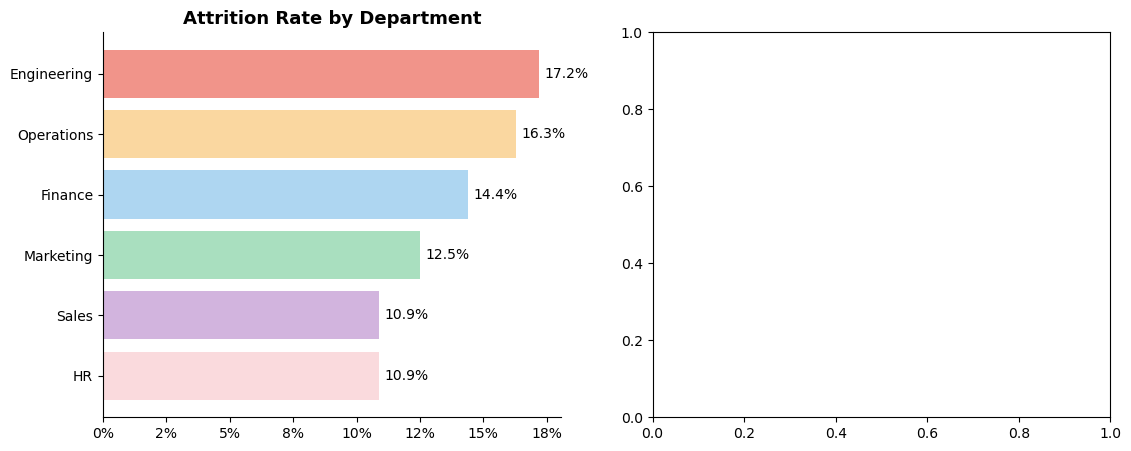

In [14]:
#4.Visulization

#Chart 1 — Attrition by Department

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_attr = ["#F1948A", "#FAD7A0", "#AED6F1", "#A9DFBF", "#D2B4DE", "#FADADD"]
axes[0].barh(q1["department"], q1["attrition_rate_pct"],
             color=colors_attr, edgecolor="none")
axes[0].xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
axes[0].set_title("Attrition Rate by Department", fontsize=13, fontweight="bold")
axes[0].invert_yaxis()
for i, v in enumerate(q1["attrition_rate_pct"]):
    axes[0].text(v + 0.2, i, f"{v}%", va="center", fontsize=10)
sns.despine(ax=axes[0])


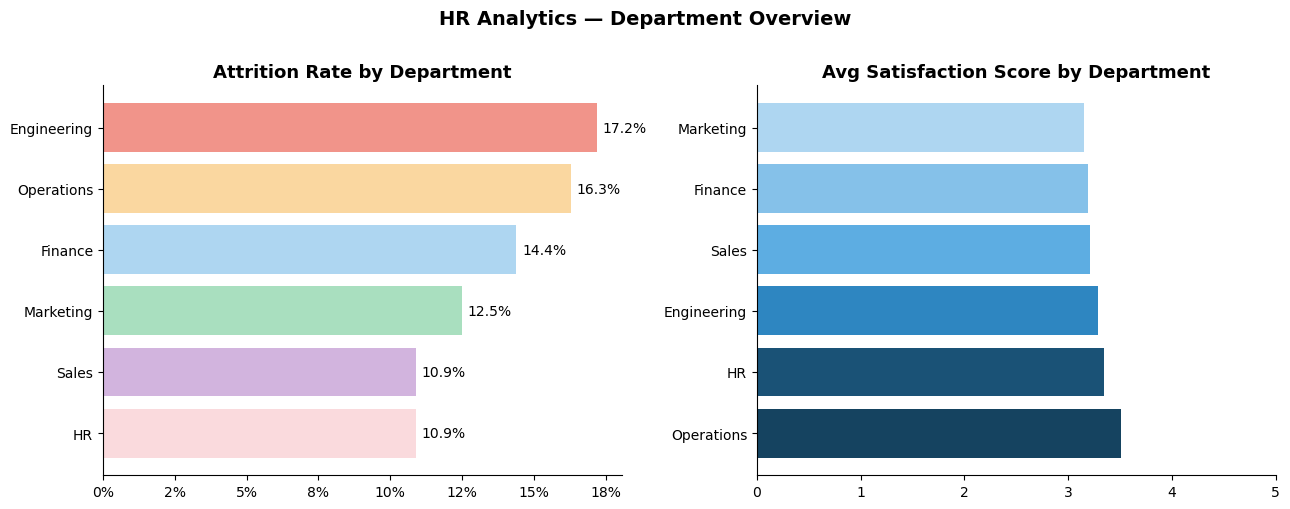

In [21]:
# Chart 2 — Avg Satisfaction by Department
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — Attrition by department
colors_attr = ["#F1948A", "#FAD7A0", "#AED6F1", "#A9DFBF", "#D2B4DE", "#FADADD"]
axes[0].barh(q1["department"], q1["attrition_rate_pct"],
             color=colors_attr, edgecolor="none")
axes[0].xaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
axes[0].set_title("Attrition Rate by Department", fontsize=13, fontweight="bold")
axes[0].invert_yaxis()
for i, v in enumerate(q1["attrition_rate_pct"]):
    axes[0].text(v + 0.2, i, f"{v}%", va="center", fontsize=10)
sns.despine(ax=axes[0])

# Right — Avg Satisfaction by Department
colors_sat = ["#AED6F1", "#85C1E9", "#5DADE2", "#2E86C1", "#1A5276", "#154360"]
dept_order = q3.sort_values("avg_satisfaction")
axes[1].barh(dept_order["department"], dept_order["avg_satisfaction"],
             color=colors_sat, edgecolor="none")
axes[1].set_xlim(0, 5)
axes[1].set_title("Avg Satisfaction Score by Department", fontsize=13, fontweight="bold")
axes[1].invert_yaxis()
sns.despine(ax=axes[1])

plt.suptitle("HR Analytics — Department Overview", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("outputs/dept_overview.png", dpi=150, bbox_inches="tight")
plt.show()

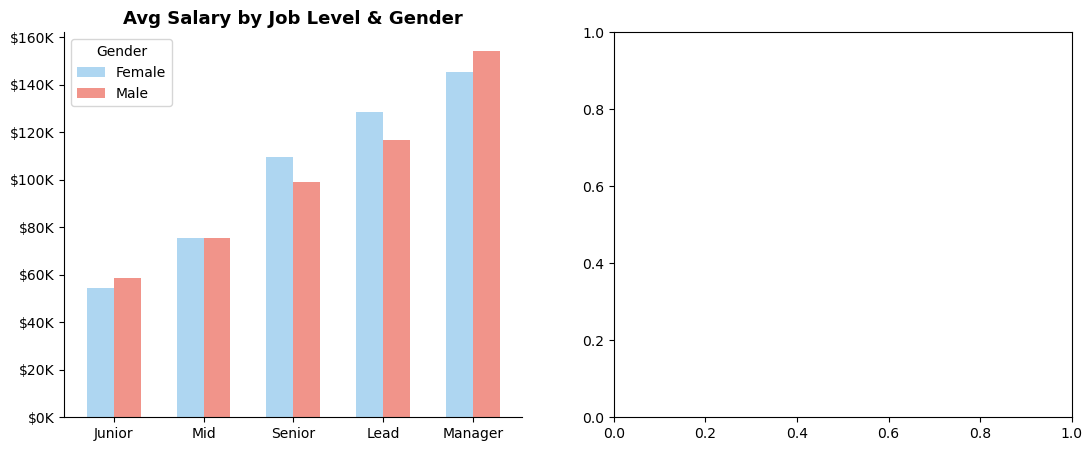

In [16]:
# Chart 2 — Salary by Job Level & Gender
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

pivot = q2.pivot(index="job_level", columns="gender", values="avg_salary")
level_order = ["Junior", "Mid", "Senior", "Lead", "Manager"]
pivot = pivot.reindex(level_order)
pivot.plot(kind="bar", ax=axes[0],
           color=["#AED6F1", "#F1948A"], edgecolor="none", width=0.6)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
axes[0].set_title("Avg Salary by Job Level & Gender", fontsize=13, fontweight="bold")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Gender")
sns.despine(ax=axes[0])

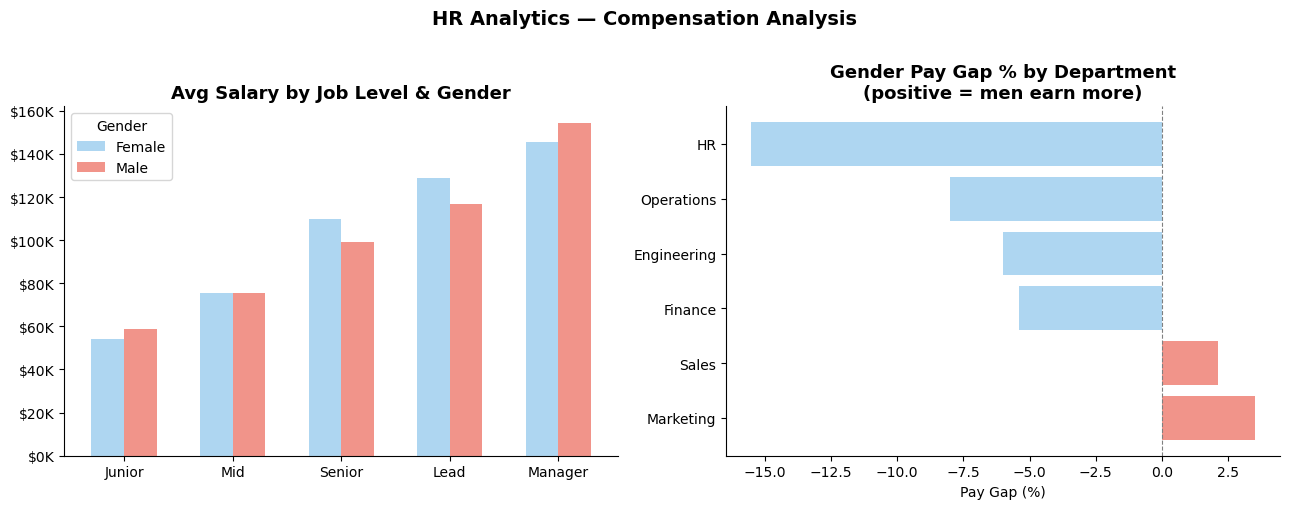

In [20]:
# Pay gap chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — Salary by Job Level & Gender
pivot = q2.pivot(index="job_level", columns="gender", values="avg_salary")
level_order = ["Junior", "Mid", "Senior", "Lead", "Manager"]
pivot = pivot.reindex(level_order)
pivot.plot(kind="bar", ax=axes[0], color=["#AED6F1", "#F1948A"],
           edgecolor="none", width=0.6)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
axes[0].set_title("Avg Salary by Job Level & Gender", fontsize=13, fontweight="bold")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Gender")
sns.despine(ax=axes[0])

# Right — Pay gap chart
axes[1].barh(q8["department"], q8["pay_gap_pct"],
             color=["#F1948A" if x > 0 else "#AED6F1" for x in q8["pay_gap_pct"]],
             edgecolor="none")
axes[1].axvline(0, color="gray", linewidth=0.8, linestyle="--")
axes[1].set_title("Gender Pay Gap % by Department\n(positive = men earn more)",
                  fontsize=13, fontweight="bold")
axes[1].set_xlabel("Pay Gap (%)")
sns.despine(ax=axes[1])

plt.suptitle("HR Analytics — Compensation Analysis", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("outputs/compensation.png", dpi=150, bbox_inches="tight")
plt.show()

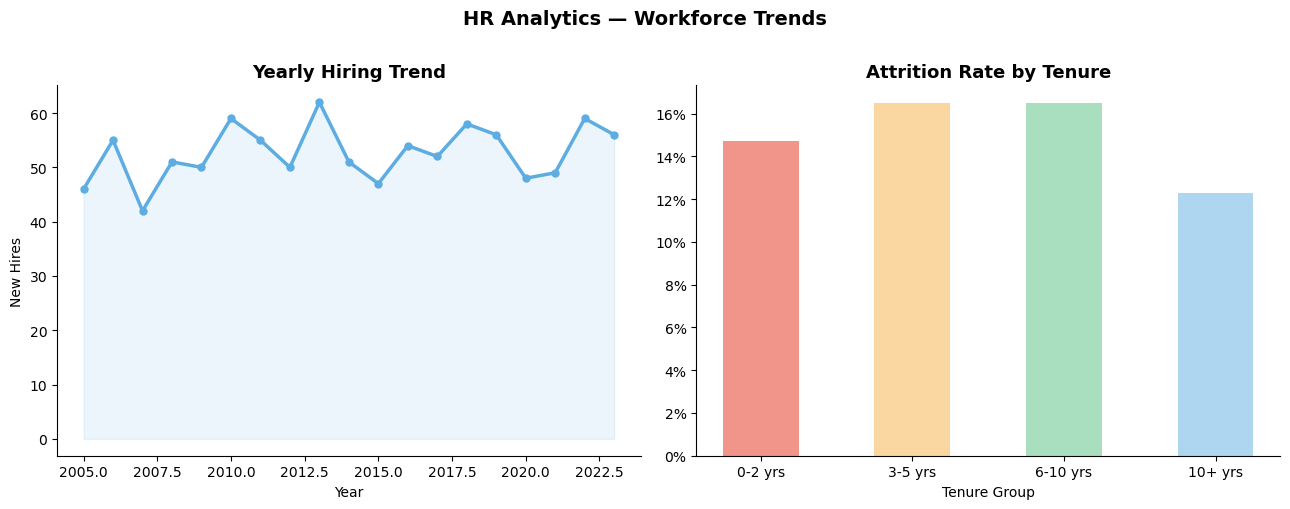

In [18]:
# Chart 3 — Hiring Trend & Tenure Attrition
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(q9["hire_year"], q9["new_hires"],
             color="#5DADE2", linewidth=2.5, marker="o", markersize=5)
axes[0].fill_between(q9["hire_year"], q9["new_hires"], alpha=0.12, color="#5DADE2")
axes[0].set_title("Yearly Hiring Trend", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("New Hires")
sns.despine(ax=axes[0])

tenure_colors = ["#F1948A", "#FAD7A0", "#A9DFBF", "#AED6F1"]
axes[1].bar(q6["tenure_bucket"], q6["attrition_pct"],
            color=tenure_colors, edgecolor="none", width=0.5)
axes[1].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
axes[1].set_title("Attrition Rate by Tenure", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Tenure Group")
sns.despine(ax=axes[1])

plt.suptitle("HR Analytics — Workforce Trends", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("outputs/workforce_trends.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# ── 5. KEY INSIGHTS ──────────────────────────────────────────
print("\n📌 KEY INSIGHTS")
print("─" * 45)
top_attr_dept = q1.iloc[0]
print(f"🔴 Highest attrition: {top_attr_dept['department']} ({top_attr_dept['attrition_rate_pct']}%)")

ot = q4[q4["overtime_status"] == "Overtime"]["attrition_rate_pct"].values[0]
no_ot = q4[q4["overtime_status"] == "No Overtime"]["attrition_rate_pct"].values[0]
print(f"⚠️  Overtime attrition: {ot}% vs No Overtime: {no_ot}%")

top_gap = q8.iloc[0]
print(f"💰 Largest pay gap: {top_gap['department']} ({top_gap['pay_gap_pct']}%)")

at_risk = len(q10)
print(f"🚨 High performers at risk: {at_risk} employees")

best_perf = q7.iloc[-1]
print(f"📈 Top performers avg training: {best_perf['avg_training_hours']} hrs/year")

conn.close()
print("\n✅ Analysis complete! Charts saved to outputs/")



📌 KEY INSIGHTS
─────────────────────────────────────────────
🔴 Highest attrition: Engineering (17.2%)
⚠️  Overtime attrition: 14.3% vs No Overtime: 14.3%
💰 Largest pay gap: Marketing (3.5%)
🚨 High performers at risk: 15 employees
📈 Top performers avg training: 42.8 hrs/year

✅ Analysis complete! Charts saved to outputs/
